## Interprétation d'un classifieur MLP

Nous allons travailler sur les données 'breast cancer'

https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic

Sur  ces données, nous allons entrainer un réseau de neurone simple (MLP - Multilayer Perceptron) et
1. calculer l'importance des variables avec un test de permutation (Permutation feature importance)
2. afficher une courbe ICE (Individual Conditional Expectation) pour la variable de plus grande importance
3. explication contre-factuelle (pour le premier exemple de la base de test) en utilisant la méthode Nelder-Mead.

[optionnel] reprendre le même travail avec un autre classifieur (gradient boosting par exemple)

In [22]:
import numpy as np
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_breast_cancer
from sklearn.inspection import PartialDependenceDisplay

import matplotlib.pyplot as plt

from scipy.optimize import minimize

# chargement des données
data = load_breast_cancer()
X, y = data.data, data.target
feature_names = data.feature_names

# séparation des jeux de données d'apprentissage et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# apprentissage du MLP
mlp = MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, random_state=42)
mlp.fit(X_train, y_train)

# evaluation du MLP
baseline_accuracy = accuracy_score(y_test, mlp.predict(X_test))
print(f"Baseline Accuracy: {baseline_accuracy:.2f}")

Baseline Accuracy: 0.94


In [6]:
# calcul de l'importance
# on peut essayer de définir une fonction de la forme
def my_permutation_importance(model, X_test, y_test, metric=accuracy_score, n_repeats=10):
    score_perm={}
    for i in range(X_test.shape[1]):
        permut=[]
        for k in range(n_repeats):
            X_temp=X_test.copy()
            np.random.shuffle(X_temp[:,i])
            res=metric(y_test,model.predict(X_temp))
            permut.append(np.abs(res-baseline_accuracy))
        score_perm[i]=np.mean(np.array(permut))
        
    return sorted(score_perm.items(), key=lambda score_perm: score_perm[1],reverse=True)

    
# affichage textuel de l'importance calculée sur 10 répétitions
# Optionel: diagramme de importance


In [7]:
my_permutation_importance(mlp, X_test, y_test, metric=accuracy_score, n_repeats=10)

[(23, np.float64(0.5289473684210526)),
 (22, np.float64(0.21228070175438601)),
 (2, np.float64(0.07192982456140355)),
 (3, np.float64(0.06228070175438599)),
 (13, np.float64(0.02719298245614038)),
 (0, np.float64(0.021052631578947333)),
 (1, np.float64(0.008771929824561342)),
 (21, np.float64(0.0061403508771929235)),
 (12, np.float64(0.005263157894736836)),
 (26, np.float64(0.004385964912280715)),
 (20, np.float64(0.00350877192982455)),
 (4, np.float64(0.0)),
 (5, np.float64(0.0)),
 (6, np.float64(0.0)),
 (7, np.float64(0.0)),
 (8, np.float64(0.0)),
 (9, np.float64(0.0)),
 (10, np.float64(0.0)),
 (11, np.float64(0.0)),
 (14, np.float64(0.0)),
 (15, np.float64(0.0)),
 (16, np.float64(0.0)),
 (17, np.float64(0.0)),
 (18, np.float64(0.0)),
 (19, np.float64(0.0)),
 (24, np.float64(0.0)),
 (25, np.float64(0.0)),
 (27, np.float64(0.0)),
 (28, np.float64(0.0)),
 (29, np.float64(0.0))]

In [19]:
data.data

array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]], shape=(569, 30))

In [17]:
feature_names

array(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error',
       'fractal dimension error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry', 'worst fractal dimension'], dtype='<U23')

In [8]:
from sklearn.inspection import permutation_importance
r = permutation_importance(mlp, X_test, y_test,
                           n_repeats=50,
                           random_state=0)
for i in r.importances_mean.argsort()[::-1]:
  
        print(f"{data.feature_names[i]:<8}"
              f"{r.importances_mean[i]:.3f}"
              f" +/- {r.importances_std[i]:.3f}")

worst area0.534 +/- 0.043
worst perimeter0.210 +/- 0.029
mean area0.074 +/- 0.024
mean perimeter0.070 +/- 0.031
area error0.026 +/- 0.017
worst concavity0.003 +/- 0.005
worst compactness0.001 +/- 0.003
worst radius0.000 +/- 0.004
worst smoothness0.000 +/- 0.000
fractal dimension error0.000 +/- 0.000
concave points error0.000 +/- 0.000
worst concave points0.000 +/- 0.000
worst fractal dimension0.000 +/- 0.000
worst symmetry0.000 +/- 0.000
mean smoothness0.000 +/- 0.000
concavity error0.000 +/- 0.000
symmetry error0.000 +/- 0.000
compactness error0.000 +/- 0.000
mean fractal dimension0.000 +/- 0.000
radius error0.000 +/- 0.000
smoothness error0.000 +/- 0.000
texture error0.000 +/- 0.000
mean compactness0.000 +/- 0.000
mean symmetry0.000 +/- 0.000
mean concave points0.000 +/- 0.000
mean concavity0.000 +/- 0.000
perimeter error-0.000 +/- 0.007
worst texture-0.005 +/- 0.005
mean texture-0.005 +/- 0.005
mean radius-0.017 +/- 0.010


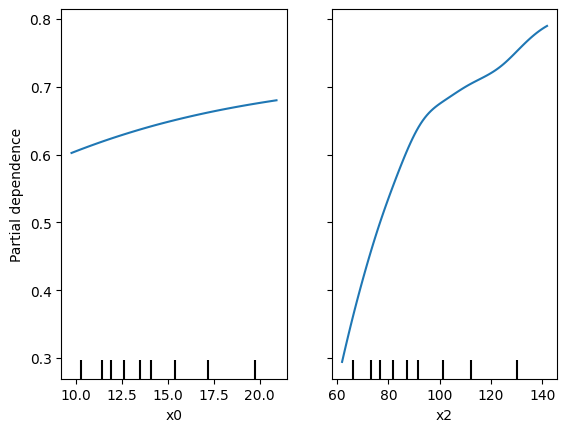

In [42]:
# identification de la variable avec la plus grande importance
from sklearn.inspection import PartialDependenceDisplay

# calcul de l'ICE
#on peut essayer de définir une fonction de la forme
def plot_ice(model, X_test, feature_name, n_points=50):
    PartialDependenceDisplay.from_estimator(model, X_test, [0,2])

plot_ice(mlp,X_test,feature_names)

y


In [ ]:
#explication contre-factuelle

# On choisit le premier exemple pour générer son explication contre-factuelle
example_idx = 0
x_instance = X_test[example_idx].reshape(1, -1)
true_label = y_test[example_idx]
print(f"True label: {true_label}")

# on définit la fonction de coût pour l'optimisation contre-factuelle
def counterfactual_cost(x_cf, x_instance, model, target_class, regularization=0.01):
    # prédiciton de la classe de l'exemple contre-factuel
    pred_prob = model.predict_proba(x_cf.reshape(1, -1))[0, target_class]
    # Distance entre l'exemple original et l'exemple contre-factuel
    dist = np.sum(np.square(x_cf - x_instance))
    # Pénalité pour minimiser les modifications et atteindre la classe cible
    return dist + regularization * (1 - pred_prob)

# classe cible pour l'explication et initialisation du problème d'optimisation
target_class = 1 if true_label == 0 else 0
x_cf_initial = X_test[example_idx].copy()

# On utilisera la fonction minimize de SciPy (avec la méthode Nelder-Mead)

# Comparaison entre l'instance originale et l'exemple contre-factuel
x_cf = result.x

# vérification de la prédiction du MLP pour l'exemple contre-factuelle (et l'original)


# Affichage des résultats


# Affichage des changements dans les caractéristiques (entre l'original et le contre-factuel)
